In [ ]:
# Rainfall Prediction Model using XGBoost

This notebook builds a machine learning model to predict:
- Probability of rainfall for the next day

### Dataset
- Source: Meteostat (processed daily weather data)
- Location: Kolkata
- Features include:
  - Temperature statistics
  - Humidity
  - Pressure
  - Rainfall
  - Wind speed
  - Cloud cover

### Objective
Predict the probability of next-day rainfall occurrence using historical weather patterns and temporal feature engineering.

### Approach
- Time-series feature engineering using:
  - Lag features
  - Rolling statistics
- Binary rainfall classification
- XGBoost Classifier for probability prediction

In [ ]:
## Data Loading and Preprocessing

# We load the cleaned daily weather dataset and convert the date column
# into datetime format for time-series operations.

# The dataset is sorted chronologically to preserve temporal order,
# which is important for rainfall forecasting.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
daily = pd.read_csv("kolkata_daily_data_new.csv")

# Convert date column to datetime format
daily['date'] = pd.to_datetime(daily['date'])

# Sort data chronologically
daily = daily.sort_values('date')

# Display first few rows
daily.head()

,date,temp_max,temp_min,temp_median,pressure_mean,humidity_mean,rain_total,wind_mean,cloud_mean,day_of_year,day_sin,day_cos
0,2005-07-07 00:00:00+00:00,27.067501,26.067501,26.567501,999.559859,94.041586,0.0,6.884644,20.428571,188,-0.094537,-0.995521
1,2005-07-08 00:00:00+00:00,31.417501,26.067501,28.092500,998.801579,83.380660,1.2,11.219267,90.375000,189,-0.111659,-0.993747
2,2005-07-09 00:00:00+00:00,31.467500,26.117500,27.917500,998.089268,83.439653,3.7,10.850390,89.125000,190,-0.128748,-0.991677
3,2005-07-10 00:00:00+00:00,30.467500,25.767500,27.592500,1000.118669,84.033518,9.2,16.631359,91.708333,191,-0.145799,-0.989314
4,2005-07-11 00:00:00+00:00,30.867500,25.967500,27.692501,1002.704005,86.510932,7.4,15.193114,97.250000,192,-0.162807,-0.986658


In [ ]:
## Feature Engineering

# We create:
# - Lag features (previous day values)
# - Rolling statistical features (recent weather trends)

# These features help capture temporal dependencies and
# short-term atmospheric changes related to rainfall patterns.

In [2]:
# Features used for lag generation
lag_features = [
    'temp_max',
    'temp_min',
    'temp_median',
    'humidity_mean',
    'pressure_mean',
    'rain_total',
    'wind_mean',
    'cloud_mean'
]

# Create lag features (previous 7 days)
for col in lag_features:
    for lag in range(1, 8):
        daily[f'{col}_lag{lag}'] = daily[col].shift(lag)

In [3]:
# Rolling statistics for temperature trends
for col in ['temp_max', 'temp_min', 'temp_median']:
    daily[f'{col}_roll7_mean'] = daily[col].rolling(7).mean()
    daily[f'{col}_roll7_std'] = daily[col].rolling(7).std()

# Rolling atmospheric features
daily['humidity_roll7_mean'] = daily['humidity_mean'].rolling(7).mean()
daily['pressure_roll7_mean'] = daily['pressure_mean'].rolling(7).mean()

# Rolling rainfall accumulation
daily['rain_roll3_sum'] = daily['rain_total'].rolling(3).sum()
daily['rain_roll7_sum'] = daily['rain_total'].rolling(7).sum()

# Rolling cloud cover trend
daily['cloud_roll7_mean'] = daily['cloud_mean'].rolling(7).mean()

In [ ]:
## Target Variable Creation

# We create a binary target variable for next-day rainfall prediction.

# If the next day's rainfall is greater than or equal to 1 mm:
# - 1 → Rain
# - 0 → No Rain

# This converts the problem into a binary classification task.

In [4]:
# Create binary rainfall target for next-day prediction
daily['rain_target'] = (daily['rain_total'].shift(-1) >= 1).astype(int)

# Remove rows containing NaN values generated from lag/rolling operations
daily = daily.dropna().reset_index(drop=True)

# Check class distribution
daily['rain_target'].value_counts()

rain_target
0    4251
1    3049
Name: count, dtype: int64

In [ ]:
## Train-Test Split

# We split the dataset chronologically:
# - Training set: Before 2022
# - Testing set: 2022 onwards

# Time-based splitting is important in weather forecasting
# to prevent future information leakage and preserve temporal order.

In [5]:
# Time-based split (important for time-series forecasting)
train = daily[daily['date'] < '2022-01-01']
test  = daily[daily['date'] >= '2022-01-01']

In [ ]:
## Feature Selection

# We exclude:
# - Date column
# - Target variable
# - Current-day rainfall column

# Remaining columns are used as input features
# for next-day rainfall prediction.

In [6]:
# Select input feature columns
feature_cols = [col for col in daily.columns if 
                col not in ['date',
                            'rain_total',
                            'rain_target']]

# Training features and target
X_train = train[feature_cols]
Y_train = train['rain_target']

# Testing features and target
X_test = test[feature_cols]
Y_test = test['rain_target']

In [ ]:
## Model Training

# We use:
# - XGBoost Classifier

# The model learns rainfall patterns from historical weather features
# and predicts the probability of rainfall occurrence for the next day.

In [7]:
from xgboost import XGBClassifier

# Initialize XGBoost classifier
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42
)

# Train model
model.fit(X_train, Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
## Model Evaluation

# We evaluate model performance using:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC Score

# These metrics help measure classification performance
# and rainfall detection capability.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Predict rainfall probabilities
train_probs = model.predict_proba(X_train)[:,1]
test_probs = model.predict_proba(X_test)[:,1]

# Lower threshold for higher rain sensitivity
train_preds = (train_probs >= 0.36).astype(int)
test_preds = (test_probs >= 0.36).astype(int)

# Accuracy
print("Train Accuracy:",
      accuracy_score(Y_train, train_preds))

print("Test Accuracy:",
      accuracy_score(Y_test, test_preds))

# ROC-AUC Score
print("ROC-AUC Score:",
      roc_auc_score(Y_test, test_probs))

# Classification report
print("\nClassification Report:\n")
print(classification_report(Y_test, test_preds))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(Y_test, test_preds))

Train Accuracy: 0.9364921030756442
Test Accuracy: 0.846692607003891
ROC-AUC Score: 0.9209615828816032

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       719
           1       0.83      0.81      0.82       566

    accuracy                           0.85      1285
   macro avg       0.85      0.84      0.84      1285
weighted avg       0.85      0.85      0.85      1285


Confusion Matrix:

[[628  91]
 [106 460]]


In [ ]:
## Visualization

# We visualize:
# - Actual vs Predicted rainfall occurrence
# - Predicted rainfall probabilities

# These plots help understand classification behavior
# and model confidence.

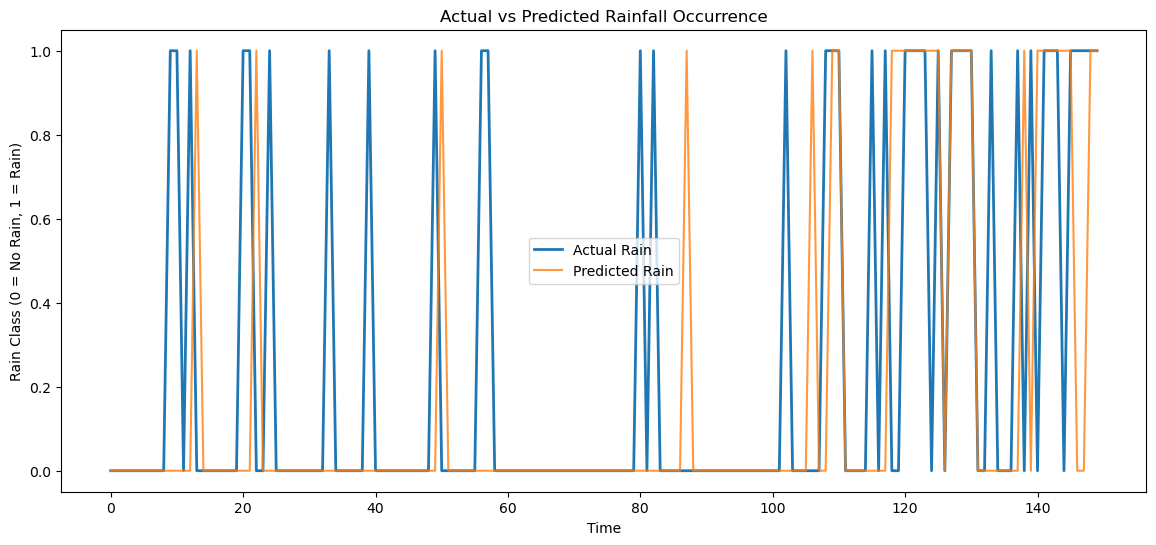

In [9]:
import matplotlib.pyplot as plt

# Plot actual vs predicted rainfall classes
plt.figure(figsize=(14,6))

plt.plot(Y_test.values[:150],
         label="Actual Rain",
         linewidth=2)

plt.plot(test_preds[:150],
         label="Predicted Rain",
         alpha=0.8)

plt.legend()
plt.title("Actual vs Predicted Rainfall Occurrence")
plt.xlabel("Time")
plt.ylabel("Rain Class (0 = No Rain, 1 = Rain)")
plt.show()

In [ ]:
## Rainfall Probability Visualization

# We visualize predicted rainfall probabilities
# to analyze model confidence levels.

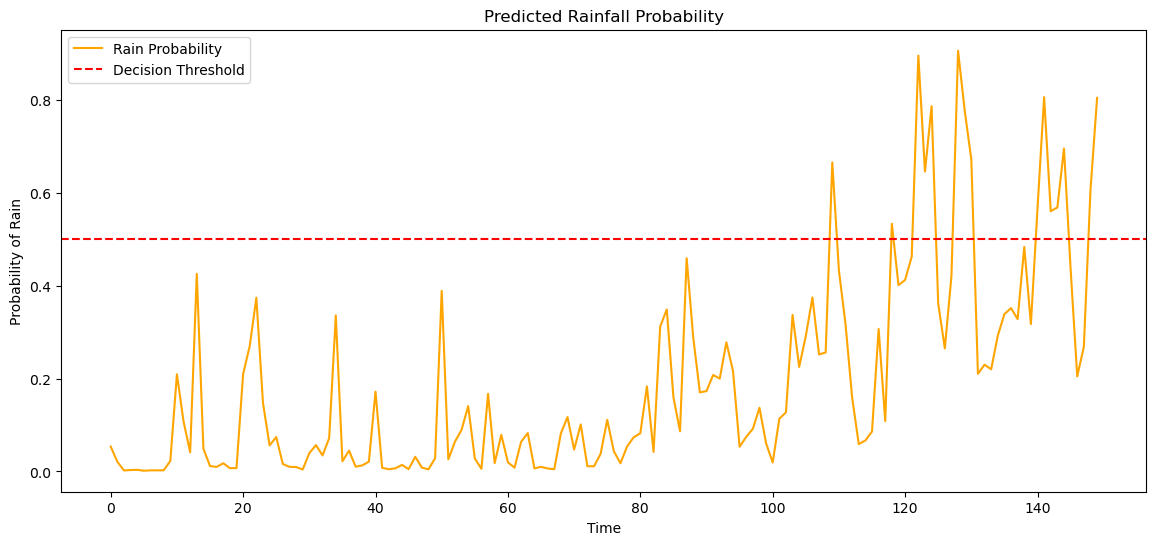

In [10]:
# Plot rainfall probabilities
plt.figure(figsize=(14,6))

plt.plot(test_probs[:150],
         label="Rain Probability",
         color='orange')

plt.axhline(0.5,
            color='red',
            linestyle='--',
            label='Decision Threshold')

plt.legend()
plt.title("Predicted Rainfall Probability")
plt.xlabel("Time")
plt.ylabel("Probability of Rain")
plt.show()

In [ ]:
## Rainfall Event Visualization

# We visualize:
# - Actual rainfall occurrences
# - Predicted rainfall occurrences

# A scatter plot is used instead of a continuous line plot
# because rainfall prediction is a binary classification problem.

# This visualization helps analyze:
# - Rain detection capability
# - Missed rainfall events
# - False rainfall alarms
# - Overall classification behavior over time

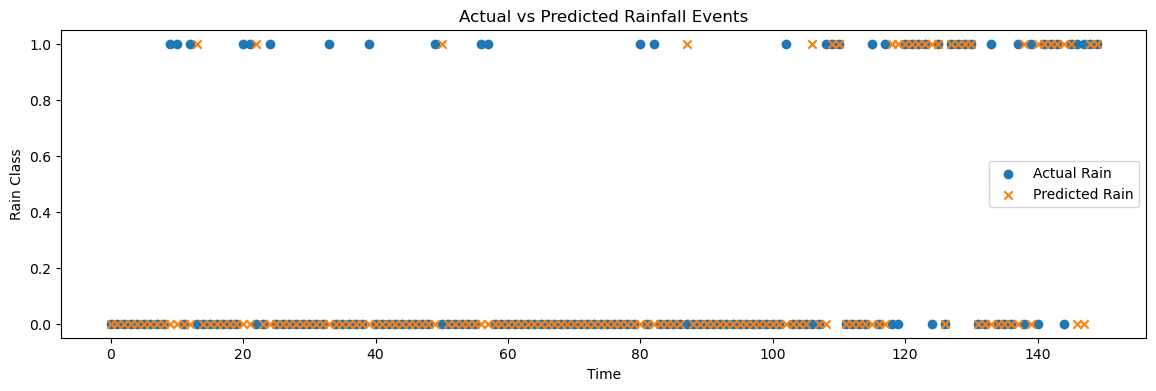

In [11]:
plt.figure(figsize=(14,4))

plt.scatter(range(150),
            Y_test.values[:150],
            label='Actual Rain',
            marker='o')

plt.scatter(range(150),
            test_preds[:150],
            label='Predicted Rain',
            marker='x')

plt.legend()
plt.title("Actual vs Predicted Rainfall Events")
plt.xlabel("Time")
plt.ylabel("Rain Class")
plt.show()

In [ ]:
## Error Analysis

# We analyze:
# - Monthly prediction performance
# - Seasonal rainfall prediction behavior

# This helps identify periods where rainfall forecasting
# becomes more difficult due to changing weather conditions.

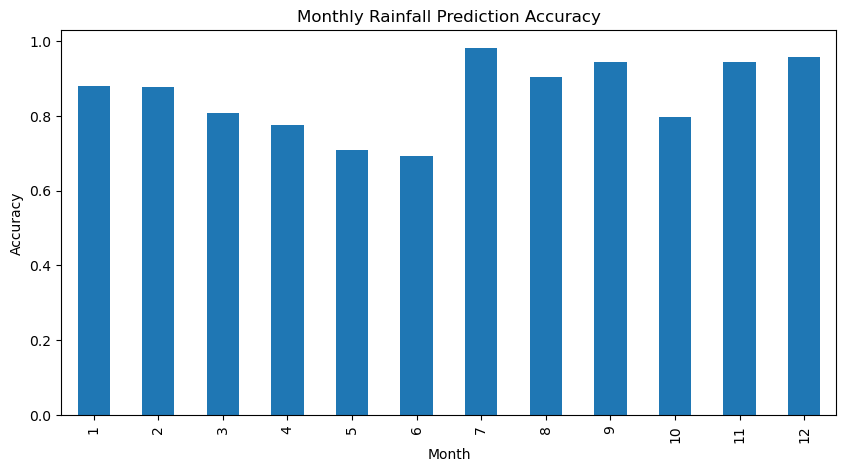

In [12]:
# Create analysis dataframe
test_copy = test.copy()

test_copy['actual'] = Y_test.values
test_copy['predicted'] = test_preds
test_copy['month'] = test_copy['date'].dt.month

# Error column
test_copy['correct_prediction'] = (
    test_copy['actual'] == test_copy['predicted']
).astype(int)

# Monthly accuracy
monthly_accuracy = test_copy.groupby('month')[
    'correct_prediction'
].mean()

# Plot monthly accuracy
plt.figure(figsize=(10,5))

monthly_accuracy.plot(kind='bar')

plt.title("Monthly Rainfall Prediction Accuracy")
plt.xlabel("Month")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
## Feature Importance Analysis

# We analyze the importance of input weather features
# used by the XGBoost classifier.

# Feature importance helps identify:
# - Which weather parameters most influence rainfall prediction
# - Temporal patterns affecting rainfall occurrence
# - The contribution of lag and rolling trend features

# This improves interpretability of the rainfall forecasting model.

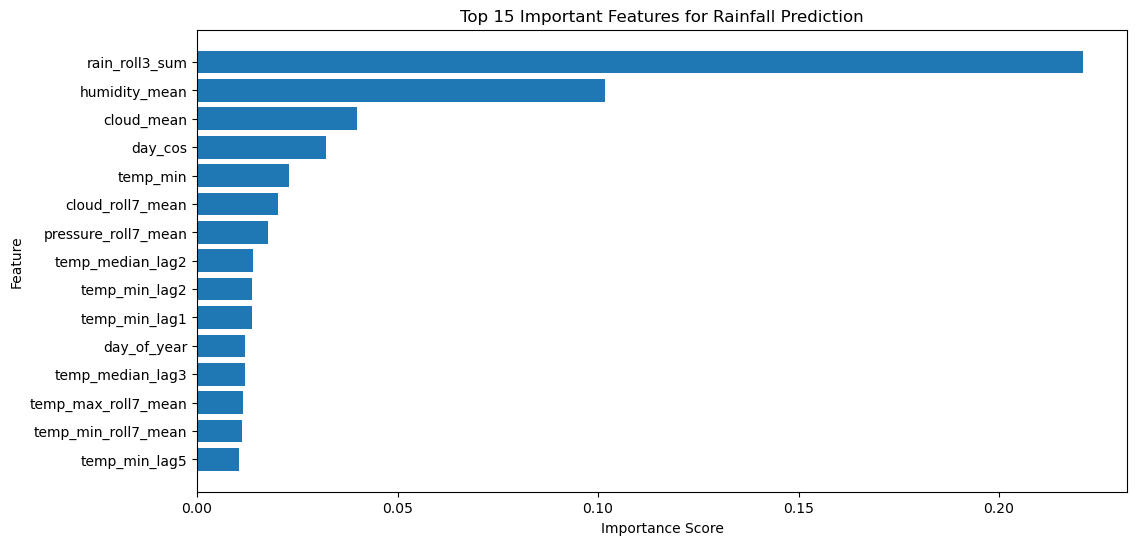

In [13]:
# Get feature importance scores
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 important features
top_features = feature_importance.head(15)

# Plot feature importance
plt.figure(figsize=(12,6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title("Top 15 Important Features for Rainfall Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [ ]:
## Prediction on New Data

# We test the trained rainfall prediction model
# using the latest available weather feature data.

# The model outputs:
# - Probability of rainfall
# - Weather classification

# This simulates real-world weather forecasting usage.

In [30]:
# Create latest input sample using most recent feature row
X_input_df = daily[feature_cols].tail(1)

# Predict rainfall probability
rain_probability = model.predict_proba(X_input_df)[:,1]

# Apply optimized threshold
rain_prediction = (rain_probability >= 0.36).astype(int)

# Convert probability into percentage
rain_percentage = rain_probability * 100

# Convert prediction into weather class
weather_class = [
    "Rain Likely" if p == 1 else "No Rain Expected"
    for p in rain_prediction
]

# Display prediction
for i in range(len(rain_percentage)):
    print(f"Sample {i+1}")
    print(f"Rain Probability: {rain_percentage[i]:.2f}%")
    print(f"Weather Class: {weather_class[i]}")
    print()

Sample 1
Rain Probability: 97.56%
Weather Class: Rain Likely



In [ ]:
## Model Saving

# The trained rainfall prediction model is saved
# using joblib for deployment in the Flask API.

In [31]:
import joblib

# Save trained rainfall prediction model
joblib.dump(model, 'rainfall_model.pkl')

print("Rainfall prediction model saved successfully.")

Rainfall prediction model saved successfully.


In [ ]:
## Conclusion

- Successfully built a rainfall prediction model using XGBoost Classifier
- Captured temporal weather patterns using lag and rolling features
- Predicted rainfall probability instead of only binary rain/no-rain output
- Optimized classification threshold to improve rainfall detection capability
- Achieved strong performance with high ROC-AUC and balanced precision-recall metrics
- Feature importance analysis showed that rainfall trends, humidity, cloud cover, and seasonal patterns strongly influence rainfall occurrence
- Model is ready for deployment via Flask API